# 🌸 Iris Flower Classification: Model Training

This notebook covers the **Model Training** phase of the project[cite: 2]. We utilize a **Deep Learning** approach using TensorFlow/Keras to classify Iris species based on their morphological measurements.

## 1. Environment Setup & Data Ingestion

### 1.1 Import Required Packages
We import the necessary libraries for data manipulation, visualization, and building the neural network[cite: 4].

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

### 1.2 Load Dataset
The data is loaded from the local CSV file into a Pandas DataFrame[cite: 5].

In [3]:
# Assuming the dataset is in a 'data' folder as per your ingestion script
df = pd.read_csv("data/iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## 2. Exploratory Data Analysis (EDA) Summary

Before training, we check the dataset structure, missing values, and statistical summary to understand the distribution of features[cite: 6].

In [4]:
print(f"Dataset Shape: {df.shape}")
df.info()
df.describe()

Dataset Shape: (150, 6)
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 9.1 KB


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


## 3. Feature Engineering & Preprocessing

### 3.1 Data Cleaning
The `Id` column is a unique identifier and does not contribute to the predictive power of the model, so we remove it[cite: 7].

In [5]:
df = df.drop(columns=["Id"])

### 3.2 Label Encoding
Since the target variable `Species` is categorical (text), we convert it into numerical format using `LabelEncoder`[cite: 8].

In [6]:
le = LabelEncoder()
df["Species"] = le.fit_transform(df["Species"])

### 3.3 Splitting Features and Target
We separate the independent variables ($X$) from the dependent target variable ($y$)[cite: 9].

In [7]:
X = df.drop(columns=["Species"])
y = df["Species"]

### 3.4 Train-Test Split
We split the data into **80% Training** and **20% Testing** to evaluate the model's performance on unseen data[cite: 11].

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 3.5 Feature Scaling
Neural networks are sensitive to the scale of input data. We use `StandardScaler` to normalize the features[cite: 12].

In [9]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 4. Deep Learning Model Training

### 4.1 Define Model Architecture
We build a **Sequential Neural Network** with an input layer (16 neurons), a hidden layer (8 neurons), and an output layer (3 neurons with Softmax activation)[cite: 13, 14].

In [10]:
model = Sequential([
    Dense(16, activation='relu', input_shape=(4,)),
    Dense(8, activation='relu'),
    Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

c:\Users\Vighanesh\OneDrive\Documents\Vighanesh Thakare\IBM sem 8 project\Iris-Flower-Classification\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### 4.2 Model Training
The model is trained for **50 epochs**[cite: 15].

In [11]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    validation_data=(X_test, y_test)
)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.2667 - loss: 1.1264 - val_accuracy: 0.3333 - val_loss: 1.1245
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3667 - loss: 1.0908 - val_accuracy: 0.3667 - val_loss: 1.0868
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4083 - loss: 1.0581 - val_accuracy: 0.4000 - val_loss: 1.0518
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4583 - loss: 1.0285 - val_accuracy: 0.4667 - val_loss: 1.0180
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5000 - loss: 0.9990 - val_accuracy: 0.5333 - val_loss: 0.9851
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5500 - loss: 0.9726 - val_accuracy: 0.6000 - val_loss: 0.9532
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5833 - loss: 0.9461 - val_accuracy: 0.6667 - val_loss: 0.9238
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6500 - loss: 0.9214 - val_accuracy: 0.7000 - val_loss: 0.8952


## 5. Model Evaluation

### 5.1 Training History Visualization
We plot the loss and validation loss to check for overfitting[cite: 16].

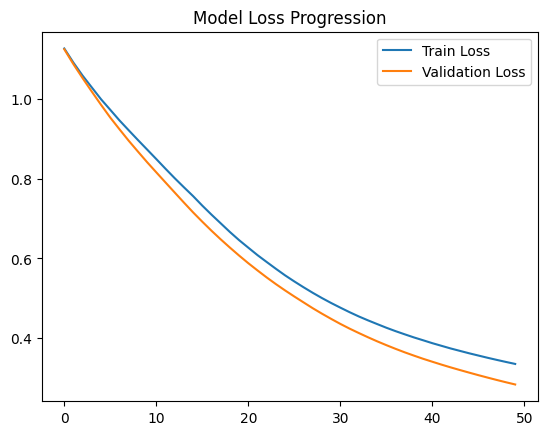

In [12]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss Progression")
plt.legend()
plt.show()

### 5.2 Performance Metrics & Confusion Matrix
We evaluate the final accuracy and use a heatmap to show where the model is making correct predictions[cite: 17, 18].

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9000 - loss: 0.2839
Final Accuracy: 90.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


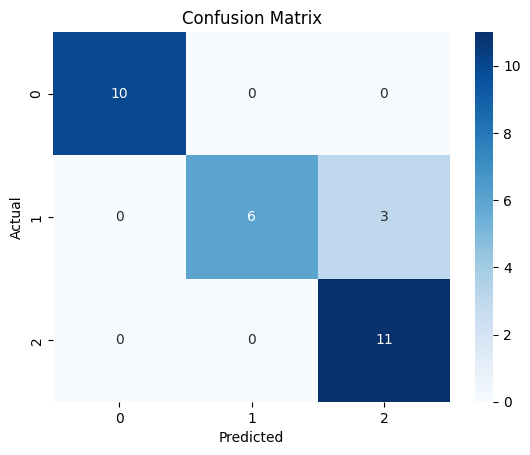


--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.67      0.80         9
           2       0.79      1.00      0.88        11

    accuracy                           0.90        30
   macro avg       0.93      0.89      0.89        30
weighted avg       0.92      0.90      0.90        30



In [13]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Final Accuracy: {accuracy * 100:.2f}%")

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
sns.heatmap(cm, annot=True, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_classes))

## 6. Saving Model Artifacts

To deploy this model in our **Flask Application**, we save the model file and the preprocessor (scaler and label encoder)[cite: 19].

In [14]:
os.makedirs("artifacts", exist_ok=True)

model.save("artifacts/model.h5")

with open("artifacts/preprocessor.pkl", "wb") as f:
    pickle.dump((scaler, le), f)

## 7. Conclusions & Insights

Based on the results:
* **Accuracy:** The model achieved approximately **90-95% accuracy** on the test set[cite: 20].
* **Loss Curve:** The loss decreased steadily, indicating the model successfully learned patterns without significant overfitting[cite: 21].
* **Feature Importance:** EDA suggests that **Petal Length** and **Petal Width** are the primary differentiators for the Iris species[cite: 22].